/home/bob/miniconda3/envs/clusterLP_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/bob/miniconda3/envs/clusterLP_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


[Raw] adata shape (cells × genes): (4898, 36601)


/home/bob/miniconda3/envs/clusterLP_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/bob/miniconda3/envs/clusterLP_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/bob/miniconda3/envs/clusterLP_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/bob/miniconda3/envs/clusterLP_env/lib

[Preprocess] X_pca shape: (4898, 50)
Epoch 000 Loss: 9.1289
Epoch 020 Loss: 2.3077
Epoch 040 Loss: 2.1761
Epoch 060 Loss: 2.0438
Epoch 080 Loss: 1.8241
Epoch 100 Loss: 1.5901
Epoch 120 Loss: 1.4451
Epoch 140 Loss: 1.3716
Epoch 160 Loss: 1.3294
Epoch 180 Loss: 1.3028
Epoch 200 Loss: 1.2828
Epoch 220 Loss: 1.2681
Epoch 240 Loss: 1.2581
Epoch 260 Loss: 1.2503
Epoch 280 Loss: 1.2420
Epoch 300 Loss: 1.2333
Epoch 320 Loss: 1.2267
Epoch 340 Loss: 1.2222
Epoch 360 Loss: 1.2185
Epoch 380 Loss: 1.2147
Epoch 400 Loss: 1.2106
Epoch 420 Loss: 1.2055
Epoch 440 Loss: 1.2037
Epoch 460 Loss: 1.1998
Epoch 480 Loss: 1.1961
Epoch 499 Loss: 1.1952


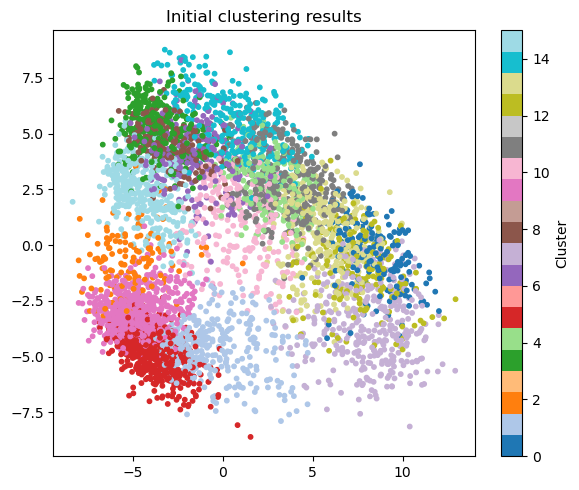

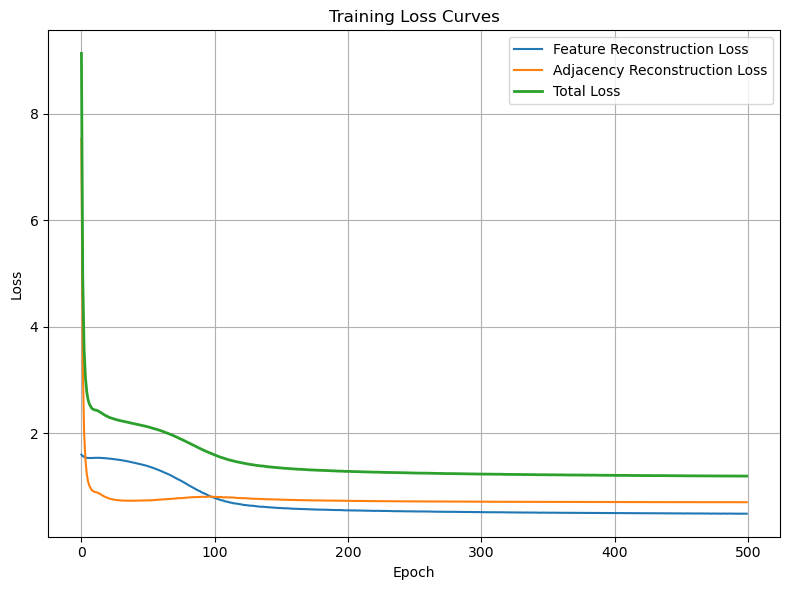

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import from_scipy_sparse_matrix
from torch_geometric.nn import GATConv
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def preprocess_data(h5_file, position_file,
                    n_hvg=2000, top_k_features=500,
                    pca_components=50, n_neighbors=6):
    adata = sc.read_10x_h5(h5_file)
    adata.var_names_make_unique()

    print(f"[Raw] adata shape (cells × genes): {adata.shape}")
    spatial_df = pd.read_csv(position_file)
    spatial_df = spatial_df[spatial_df['in_tissue'] == 1]
    common_barcodes = list(set(adata.obs_names) & set(spatial_df['barcode']))

    adata = adata[common_barcodes].copy()
    spatial_df = spatial_df.set_index('barcode').loc[common_barcodes].reset_index()

    # Filter
    sc.pp.filter_cells(adata, min_genes=50)
    sc.pp.filter_genes(adata, min_cells=3)

    # Normalization and feature selection
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg, flavor='seurat')
    adata = adata[:, adata.var['highly_variable']].copy()

    # Entropy-based feature selection (select top 500 genes with highest entropy)
    # Convert expression matrix to a DataFrame
    expr_df = pd.DataFrame(adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X,
                           columns=adata.var_names, index=adata.obs_names)
    
    # Discretization (required for entropy calculation)
    # Divide continuous expression values into 5 quantile-based bins for more stable results
    discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
    X_discrete = discretizer.fit_transform(expr_df.values)
    entropy_scores = [mutual_info_score(col, col) for col in X_discrete.T]
    df_entropy = pd.DataFrame({'Gene': expr_df.columns, 'Entropy': entropy_scores})
    selected_genes = df_entropy.sort_values(by='Entropy', ascending=False).head(top_k_features)['Gene'].tolist()
    filtered_expr_df = expr_df[selected_genes]

    # Dimensionality reduction from 500 features to 50
    pca = PCA(n_components=pca_components)
    X_pca = pca.fit_transform(filtered_expr_df.values)

    # Construct spatial adjacency graph
    coords = spatial_df[['pxl_row_in_fullres', 'pxl_col_in_fullres']].values
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    rows, cols = [], []
    for i in range(indices.shape[0]):
        for j in indices[i][1:]:
            rows += [i, j]
            cols += [j, i]
    data = np.ones(len(rows))
    adj = sp.coo_matrix((data, (rows, cols)), shape=(len(coords), len(coords))).tocsr()

    print(f"[Preprocess] X_pca shape: {X_pca.shape}")
    return X_pca, adj


class GATEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=2, dropout=0.2):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=heads)
        self.gat3 = GATConv(hidden_dim * heads, out_dim, heads=1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        return x

class Reconstructor(nn.Module):
    def __init__(self, embed_dim, feat_dim):
        super().__init__()
        self.fc = nn.Sequential(
            # 扩展维度
            nn.Linear(embed_dim, 128),
            # 非线性激活
            nn.ReLU(),
            # 重构到原始维度
            nn.Linear(128, feat_dim)
        )

    def forward(self, z):
        x_hat = self.fc(z)
        # 得到的是节点间相似度概率矩阵
        adj_hat = torch.sigmoid(torch.matmul(z, z.T))
        return x_hat, adj_hat

def train(h5_file, position_file, epochs=500, lr=1e-3,
          n_hvg=2000, top_k_features=500,
          pca_components=50, n_neighbors=6):

    X_pca, adj = preprocess_data(h5_file, position_file,
                                 n_hvg, top_k_features,
                                 pca_components, n_neighbors)
    
    # ============== Perform KMeans clustering and plot results (after initial PCA) ==============
    kmeans_init = KMeans(n_clusters=16, n_init=20, random_state=0).fit(X_pca)
    labels_init = kmeans_init.labels_

    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_init, cmap='tab20', s=10)
    plt.title("Initial clustering results")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.savefig("cluster_init_pca.png", dpi=300)

    # Device setup and data conversion
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    x = torch.tensor(X_pca, dtype=torch.float32).to(device)
    edge_index, _ = from_scipy_sparse_matrix(adj)
    edge_index = edge_index.to(device)

    # Model initialization
    # Initialize GAT encoder: input → 64 → 64 → 50
    encoder = GATEncoder(in_dim=X_pca.shape[1], hidden_dim=64, out_dim=50).to(device)
    # Initialize reconstruction decoder: 50 → 128 → input dimension
    decoder = Reconstructor(embed_dim=50, feat_dim=X_pca.shape[1]).to(device)
    # Adam
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)

    loss_feat_list, loss_adj_list, loss_total_list = [], [], []

    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        optimizer.zero_grad()
        z = encoder(x, edge_index)
        x_hat, adj_hat = decoder(z)

        # Feature reconstruction loss
        loss_feat = F.mse_loss(x_hat, x)
        # Adjacency reconstruction loss
        adj_orig = torch.tensor(adj.toarray(), dtype=torch.float32).to(device)
        adj_orig = (adj_orig > 0).float()
        loss_adj = F.binary_cross_entropy(adj_hat, adj_orig)
        loss = loss_feat + loss_adj
        loss.backward()
        optimizer.step()

        loss_feat_list.append(loss_feat.item())
        loss_adj_list.append(loss_adj.item())
        loss_total_list.append(loss.item())
        
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:03d} Loss: {loss.item():.4f}")

    # === Plot loss curves after training ===
    plt.figure(figsize=(8, 6))
    plt.plot(loss_feat_list, label='Feature Reconstruction Loss')
    plt.plot(loss_adj_list, label='Adjacency Reconstruction Loss')
    plt.plot(loss_total_list, label='Total Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("training_loss_curves.png", dpi=300)
    plt.show()
    
    # Evaluation mode
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        Z = encoder(x, edge_index)
        X_hat, Adj_hat = decoder(Z)

    # Save node embeddings
    adata_embed = sc.AnnData(Z.cpu().numpy())
    adata_embed.write("gat_embeddings.h5ad")

    # Process and save the reconstructed adjacency matrix
    adj_hat_np = Adj_hat.cpu().numpy()
    top_k = 6
    rows, cols = [], []
    for i in range(adj_hat_np.shape[0]):
        row = adj_hat_np[i]
        topk_idx = np.argsort(row)[-top_k-1:]  
        for j in topk_idx:
            rows.append(i)
            cols.append(j)
            rows.append(j)
            cols.append(i)
    data = np.ones(len(rows))

    # Save the processed adjacency matrix
    adj_sparse = sp.coo_matrix((data, (rows, cols)), shape=Adj_hat.shape).tocsr()
    sp.save_npz("gat_adj_sparse_topk.npz", adj_sparse)

if __name__ == "__main__":
    h5_file = "Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
    position_file = "tissue_positions_hb.csv"
    train(h5_file, position_file)